In [11]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml

# ## fetching the data

# df=fetch_openml(
#     name="Fashion-MNIST",
#     version=1,
#     as_frame=False,
#     parser="auto"
# )

# X=df.data
# y=df.target


In [12]:
# print(X.dtype)
# print(y.dtype)

In [13]:
## changing the dtype to int
# y=y.astype(np.int64)

In [14]:
# print(X.max())
# print(X.min())

In [15]:
# print(y.max())
# print(y.min())

In [16]:
## Normalisation
# X=X/255.0

In [17]:
# print(X.max())
# print(X.min())

In [18]:
# y.shape

In [19]:
# # Train-Test split
# X_train = X[:60000]
# y_train = y[:60000]

# X_test = X[60000:]
# y_test = y[60000:]

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

# Load Fashion-MNIST
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()

# Flatten 28x28 images into 784 features
X_train = x_train_raw.reshape(60000, 784).astype(np.float32) / 255.0
X_test = x_test_raw.reshape(10000, 784).astype(np.float32) / 255.0

y_train = y_train_raw
y_test = y_test_raw

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test : (10000, 784)
y_test : (10000,)


In [21]:
# Transpose for our implementation
X_train = X_train.T
X_test = X_test.T

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(784, 60000)
(60000,)
(784, 10000)
(10000,)


In [22]:
## one hot incoding of Y
num_classes = 10

y_train = np.eye(num_classes)[y_train].T
y_test = np.eye(num_classes)[y_test].T

In [23]:
print(y_train.shape)
print(y_test.shape)

(10, 60000)
(10, 10000)


In [24]:
## Initializing the weights and bais
W1=np.random.randn(128,784)*0.01
b1=np.zeros((128,1))

W2=np.random.randn(10,128)*0.01
b2=np.zeros((10,1))

In [25]:
## forward propogation(input layer)
Z1=np.dot(W1,X_train)+b1

In [26]:
## implementing the relu
A1=np.maximum(0,Z1)

In [27]:
## Output layer
Z2=np.dot(W2,A1)+b2

In [28]:
## Softmax
ex=np.exp(Z2-np.max(Z2,axis=0,keepdims=True))
A2=ex/np.sum(ex,axis=0,keepdims=True)

In [29]:
## cross-entropy
loss=-np.mean(np.sum(y_train*np.log(A2 + 1e-9),axis=0))

In [30]:
## caching the data for future bactracking use
cache={
    "Z1":Z1,
    "A1":A1,
    "Z2":Z2,
    "A2":A2
}

In [31]:
## retrive the cache
Z1 = cache["Z1"]
A1 = cache["A1"]
Z2 = cache["Z2"]
A2 = cache["A2"]

In [32]:
### number of data for finding mean
m=X_train.shape[1]
print(m)

60000


In [33]:
## computing dZ2
dZ2=A2-y_train

In [34]:
## computing dW2
dW2=(1/m)*np.dot(dZ2,A1.T)

In [35]:
## computing db2
db2=(1/m)*np.sum(dZ2,axis=1,keepdims=True)

In [36]:
## coputing dA1
dA1=np.dot(W2.T,dZ2)

In [37]:
## computing Relu dZ1
dZ1=dA1*(Z1>0)

In [38]:
## computing dW1
dW1=(1/m)*np.dot(dZ1,X_train.T)

In [39]:
## computing db1
db1=(1/m)*np.sum(dZ1,axis=1,keepdims=True)

In [40]:
def forward(X,W1,W2,b1,b2):

    Z1 = np.dot(W1, X)+b1

    A1 = np.maximum(0, Z1)

    Z2 = np.dot(W2, A1)+b2

    ex=np.exp(Z2-np.max(Z2,axis=0,keepdims=True))
    A2=ex/np.sum(ex,axis=0,keepdims=True)


    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return cache

In [41]:
def compute_loss(A2,Y):
  loss=-np.mean(np.sum(Y*np.log(A2 + 1e-9),axis=0))
  return loss

In [42]:
def backward(X, Y, W2, cache):

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    m = X.shape[1]

    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * (Z1 > 0)

    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

In [43]:
def update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate):

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

In [44]:
def numerical_gradient_W1(X, Y, W1, b1, W2, b2, eps=1e-5):

    grad = np.zeros_like(W1)

    for i in range(W1.shape[0]):
        for j in range(W1.shape[1]):

            original = W1[i, j]

            # L(theta + eps)
            W1[i, j] = original + eps
            cache = forward(X, W1, W2, b1, b2)
            loss_plus = compute_loss(cache["A2"], Y)

            # L(theta - eps)
            W1[i, j] = original - eps
            cache = forward(X, W1, W2, b1, b2)
            loss_minus = compute_loss(cache["A2"], Y)

            grad[i, j] = (loss_plus - loss_minus) / (2 * eps)

            W1[i, j] = original

    return grad

In [45]:
X_small = X_train[:, :10]
Y_small = y_train[:, :10]

In [46]:
cache = forward(X_small, W1, W2, b1, b2)

dW1, db1, dW2, db2 = backward(X_small, Y_small, W2, cache)

In [47]:
num_grad = numerical_gradient_W1(
    X_small,
    Y_small,
    W1,
    b1,
    W2,
    b2
)

In [48]:
relative_error = np.linalg.norm(dW1 - num_grad) / (
    np.linalg.norm(dW1) + np.linalg.norm(num_grad)
)

print("Relative Error:", relative_error)

Relative Error: 7.035094760759209e-09


The training loop

In [49]:
epoches=100
for epoch in range(epoches):
  ## forward
    cache=forward(X_train,W1,W2,b1,b2)
  ## loss
    loss=compute_loss(cache["A2"],y_train)
  ## backward
    dW1, db1, dW2, db2=backward(X_train,y_train,W2,cache)
  ## update
    W1, b1, W2, b2=update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate=0.1)

    print(epoch,loss)

0 2.301463737213296
1 2.2981351255571387
2 2.2947578735130767
3 2.291184960433109
4 2.2872935404958055
5 2.282999179236563
6 2.2782104474583007
7 2.27282694032632
8 2.26675186827092
9 2.2598923713065044
10 2.252159655750007
11 2.243467703982484
12 2.2337392359801442
13 2.22290104646616
14 2.2108816642299636
15 2.1976093686903115
16 2.1830087787663777
17 2.1669969726219214
18 2.149487582553612
19 2.130398662515023
20 2.1096588944251558
21 2.0872183262503863
22 2.063047745820988
23 2.0371440058663124
24 2.0095396411789577
25 1.9803268184182512
26 1.9496680837635316
27 1.9177996575798713
28 1.885025379624734
29 1.8516978098902688
30 1.8181900895157743
31 1.7848611644062342
32 1.7520274394403095
33 1.71994364404405
34 1.6887950737708646
35 1.6586993930358385
36 1.6297183133264685
37 1.6018720935424595
38 1.5751535129718648
39 1.5495371958128592
40 1.5249859090272686
41 1.5014537587675387
42 1.4788910134160667
43 1.457245070214684
44 1.4364629646408715
45 1.416492425061776
46 1.397282352396

In [50]:
epoches=100
for epoch in range(epoches):
  ## forward
    cache=forward(X_train,W1,W2,b1,b2)
  ## loss
    loss=compute_loss(cache["A2"],y_train)
  ## backward
    dW1, db1, dW2, db2=backward(X_train,y_train,W2,cache)
  ## update
    W1, b1, W2, b2=update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate=0.2)

    print(epoch,loss)

0 0.8997123733685278
1 0.8917198999565875
2 0.8840877143207759
3 0.8767921753223668
4 0.8698115978054897
5 0.8631256564397553
6 0.8567180287634895
7 0.8506092033335169
8 0.8452645777142175
9 0.8470821596600872
10 0.9271521961952869
11 1.2879067280832313
12 1.6846360805205682
13 1.2820761545570005
14 0.9438813969982
15 0.8609252795942173
16 0.8434876200007801
17 0.8397124131161812
18 0.8561817475902859
19 0.8715149200558452
20 0.9308071439147619
21 0.944897160049398
22 0.8972190217633089
23 0.9279613702127639
24 0.8633516971515921
25 0.8754498903897695
26 0.844856634575207
27 0.8602705678002913
28 0.8321910383622774
29 0.8476872953890745
30 0.8227338076892502
31 0.8382997216723054
32 0.8147202450077647
33 0.8298578150526573
34 0.8073042946776258
35 0.8217317175224791
36 0.8001268455045406
37 0.8138053659221706
38 0.7932244415232494
39 0.806231438894235
40 0.786562669853345
41 0.7989453720359887
42 0.7801339797922456
43 0.7919983788613045
44 0.7738920146704962
45 0.7852742222911518
46 0.

In [51]:
epoches=100
for epoch in range(epoches):
  ## forward
    cache=forward(X_train,W1,W2,b1,b2)
  ## loss
    loss=compute_loss(cache["A2"],y_train)
  ## backward
    dW1, db1, dW2, db2=backward(X_train,y_train,W2,cache)
  ## update
    W1, b1, W2, b2=update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate=0.01)

    print(epoch,loss)

0 0.6501975618203603
1 0.6448045689981988
2 0.6405270590324482
3 0.6371284457987121
4 0.6344219203942
5 0.6322595099432502
6 0.6305256627907583
7 0.6291301227492068
8 0.628001506349189
9 0.6270837598800666
10 0.6263331108203601
11 0.6257155733498042
12 0.6252034976899669
13 0.6247751585676604
14 0.6244135581484191
15 0.6241050837319041
16 0.6238390315504576
17 0.6236068648372206
18 0.6234017126077557
19 0.6232181315926738
20 0.623051836737174
21 0.6228994116219236
22 0.622758215389238
23 0.6226260442538034
24 0.6225011052909334
25 0.6223819441393438
26 0.6222674760188681
27 0.6221567845711072
28 0.6220492089637242
29 0.6219441747981693
30 0.6218412168356701
31 0.6217400010932114
32 0.621640217000816
33 0.6215416158252307
34 0.6214440167301953
35 0.6213472614330179
36 0.6212512161441012
37 0.6211557777215414
38 0.6210608886209221
39 0.6209664712207112
40 0.6208724605528005
41 0.6207788269717066
42 0.6206855604103263
43 0.6205926222619048
44 0.6204999572282605
45 0.6204075458459575
46 0.

In [52]:
epoches=100
for epoch in range(epoches):
  ## forward
    cache=forward(X_train,W1,W2,b1,b2)
  ## loss
    loss=compute_loss(cache["A2"],y_train)
  ## backward
    dW1, db1, dW2, db2=backward(X_train,y_train,W2,cache)
  ## update
    W1, b1, W2, b2=update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate=0.05)

    print(epoch,loss)

0 0.6155723465712706
1 0.6151497940223996
2 0.614729565791106
3 0.614311569922723
4 0.6138954963244191
5 0.6134814320520001
6 0.6130693291765973
7 0.6126591896418384
8 0.612250963093048
9 0.6118445387914976
10 0.6114399867076835
11 0.6110371732734361
12 0.6106363394344662
13 0.6102373500910598
14 0.6098402204068306
15 0.6094450361714807
16 0.60905135239858
17 0.6086592360662778
18 0.6082688043450721
19 0.6078800030972803
20 0.6074928106124471
21 0.6071070670771294
22 0.6067227515381651
23 0.6063398365834666
24 0.6059583493479943
25 0.6055781756563229
26 0.6051992914427368
27 0.6048218167190922
28 0.6044456728687889
29 0.6040708734790908
30 0.6036973245028201
31 0.6033251123135246
32 0.6029540415295138
33 0.6025842559384673
34 0.6022157682036906
35 0.6018485423313984
36 0.6014825255287334
37 0.6011176999427731
38 0.6007540570709297
39 0.6003915647141976
40 0.6000301683416936
41 0.5996699294374274
42 0.5993109144559022
43 0.5989530711656659
44 0.5985963625719203
45 0.5982407865790212
46 

In [55]:
# ============================================================
# Exercise 2: Trouser vs Sneaker
# ============================================================

class_a = 1   # Trouser
class_b = 7   # Sneaker

# ------------------------------------------------------------
# Convert one-hot labels back to class numbers
# y_train has shape (10, N)
# ------------------------------------------------------------

labels = np.argmax(y_train, axis=0)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("labels shape:", labels.shape)

# ------------------------------------------------------------
# Select only Trouser (1) and Sneaker (7)
# ------------------------------------------------------------

mask_train = (labels == class_a) | (labels == class_b)

X_bin = X_train[:, mask_train]
labels_bin = labels[mask_train]

# ------------------------------------------------------------
# Convert labels:
# Trouser  -> 0
# Sneaker  -> 1
# ------------------------------------------------------------

y_bin = (labels_bin == class_b).astype(np.float64)

# Make labels shape (1, N)
y_bin = y_bin.reshape(1, -1)

print("\nBinary dataset:")
print("X_bin shape:", X_bin.shape)
print("y_bin shape:", y_bin.shape)
print("Number of samples:", X_bin.shape[1])

X_train shape: (784, 60000)
y_train shape: (10, 60000)
labels shape: (60000,)

Binary dataset:
X_bin shape: (784, 12000)
y_bin shape: (1, 12000)
Number of samples: 12000


In [56]:
y_bin = y_bin.reshape(1, -1)

print("X_bin:", X_bin.shape)
print("y_bin:", y_bin.shape)

X_bin: (784, 12000)
y_bin: (1, 12000)


In [57]:
np.random.seed(42)

m = X_bin.shape[1]

indices = np.random.permutation(m)

split = int(0.8 * m)

train_idx = indices[:split]
val_idx = indices[split:]

X_bin_train = X_bin[:, train_idx]
y_bin_train = y_bin[:, train_idx]

X_bin_val = X_bin[:, val_idx]
y_bin_val = y_bin[:, val_idx]

print("Training:", X_bin_train.shape)
print("Validation:", X_bin_val.shape)

Training: (784, 9600)
Validation: (784, 2400)


In [58]:
def sigmoid_binary(z):
    return 1 / (1 + np.exp(-z))

In [59]:
def mse_binary(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

In [60]:
def binary_cross_entropy(y_pred, y_true):

    eps = 1e-9

    y_pred = np.clip(y_pred, eps, 1 - eps)

    loss = -np.mean(
        y_true * np.log(y_pred)
        +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [61]:
def train_binary_mse(X, Y, X_val, Y_val, learning_rate=0.1, epochs=50):

    n_features = X.shape[0]
    m = X.shape[1]

    # Same initialization
    np.random.seed(42)

    W = np.random.randn(1, n_features) * 0.01
    b = np.zeros((1, 1))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # -------------------------
        # Forward
        # -------------------------
        Z = np.dot(W, X) + b
        A = sigmoid_binary(Z)

        # -------------------------
        # Loss
        # -------------------------
        loss = mse_binary(A, Y)

        # -------------------------
        # Backward
        # -------------------------

        # MSE derivative:
        # dL/dA = 2(A-Y)/m
        dA = (2 / m) * (A - Y)

        # sigmoid derivative
        dZ = dA * A * (1 - A)

        dW = np.dot(dZ, X.T)
        db = np.sum(dZ, axis=1, keepdims=True)

        # -------------------------
        # Update
        # -------------------------
        W -= learning_rate * dW
        b -= learning_rate * db

        # -------------------------
        # Validation
        # -------------------------
        Z_val = np.dot(W, X_val) + b
        A_val = sigmoid_binary(Z_val)

        val_loss = mse_binary(A_val, Y_val)

        train_losses.append(loss)
        val_losses.append(val_loss)

    return W, b, train_losses, val_losses

In [62]:
def train_binary_bce(X, Y, X_val, Y_val, learning_rate=0.1, epochs=50):

    n_features = X.shape[0]
    m = X.shape[1]

    # Same initialization
    np.random.seed(42)

    W = np.random.randn(1, n_features) * 0.01
    b = np.zeros((1, 1))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # -------------------------
        # Forward
        # -------------------------
        Z = np.dot(W, X) + b
        A = sigmoid_binary(Z)

        # -------------------------
        # Loss
        # -------------------------
        loss = binary_cross_entropy(A, Y)

        # -------------------------
        # Backward
        # -------------------------

        # For sigmoid + BCE:
        # dZ = A - Y

        dZ = A - Y

        dW = (1 / m) * np.dot(dZ, X.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

        # -------------------------
        # Update
        # -------------------------
        W -= learning_rate * dW
        b -= learning_rate * db

        # -------------------------
        # Validation
        # -------------------------
        Z_val = np.dot(W, X_val) + b
        A_val = sigmoid_binary(Z_val)

        val_loss = binary_cross_entropy(A_val, Y_val)

        train_losses.append(loss)
        val_losses.append(val_loss)

    return W, b, train_losses, val_losses

In [63]:
learning_rate = 0.1
epochs = 50

In [64]:
W_mse, b_mse, mse_train_loss, mse_val_loss = train_binary_mse(
    X_bin_train,
    y_bin_train,
    X_bin_val,
    y_bin_val,
    learning_rate=learning_rate,
    epochs=epochs
)

W_bce, b_bce, bce_train_loss, bce_val_loss = train_binary_bce(
    X_bin_train,
    y_bin_train,
    X_bin_val,
    y_bin_val,
    learning_rate=learning_rate,
    epochs=epochs
)

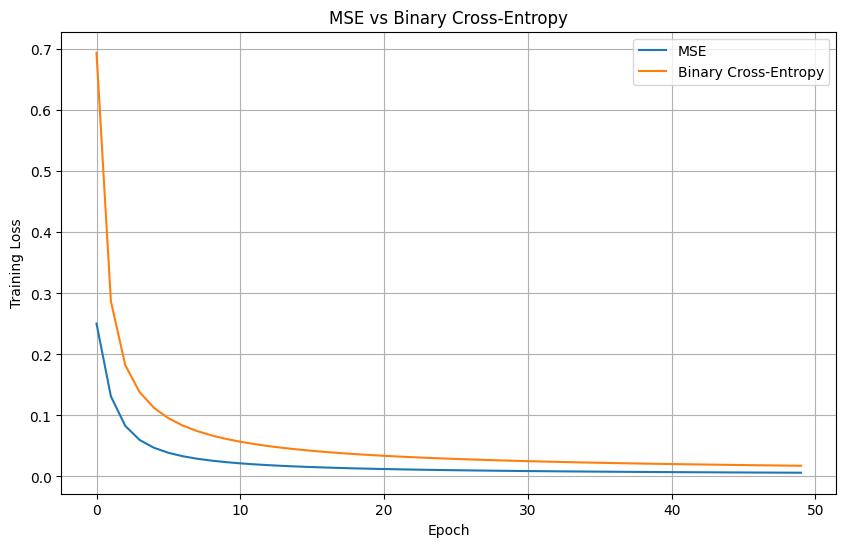

In [65]:
plt.figure(figsize=(10, 6))

plt.plot(
    mse_train_loss,
    label="MSE"
)

plt.plot(
    bce_train_loss,
    label="Binary Cross-Entropy"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MSE vs Binary Cross-Entropy")
plt.legend()
plt.grid(True)

plt.show()

In [66]:
print("Final MSE training loss:",
      mse_train_loss[-1])

print("Final BCE training loss:",
      bce_train_loss[-1])

print("Final MSE validation loss:",
      mse_val_loss[-1])

print("Final BCE validation loss:",
      bce_val_loss[-1])

Final MSE training loss: 0.006154213514507284
Final BCE training loss: 0.017577447303763764
Final MSE validation loss: 0.00659655596619336
Final BCE validation loss: 0.01857886182019142


In [67]:
def binary_accuracy(W, b, X, Y):

    Z = np.dot(W, X) + b
    probabilities = sigmoid_binary(Z)

    predictions = (probabilities >= 0.5).astype(int)

    accuracy = np.mean(predictions == Y)

    return accuracy

In [68]:
mse_accuracy = binary_accuracy(
    W_mse,
    b_mse,
    X_bin_val,
    y_bin_val
)

bce_accuracy = binary_accuracy(
    W_bce,
    b_bce,
    X_bin_val,
    y_bin_val
)

print("MSE validation accuracy:",
      mse_accuracy * 100)

print("BCE validation accuracy:",
      bce_accuracy * 100)

MSE validation accuracy: 99.95833333333334
BCE validation accuracy: 99.95833333333334


In [69]:
epochs = 20
batch_size = 128

m = X_train.shape[1]

for epoch in range(epochs):

    epoch_loss = 0

    for start in range(0, m, batch_size):

        end = min(start + batch_size, m)

        X_batch = X_train[:, start:end]
        Y_batch = y_train[:, start:end]

        # Forward
        cache = forward(X_batch, W1, W2, b1, b2)

        # Loss
        loss = compute_loss(cache["A2"], Y_batch)

        # Backward
        dW1, db1, dW2, db2 = backward(X_batch, Y_batch, W2, cache)

        # Update
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2,
            learning_rate=0.01
        )

        epoch_loss += loss

    epoch_loss /= (m + batch_size - 1) // batch_size

    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

Epoch 1: Loss = 0.5685
Epoch 2: Loss = 0.5456
Epoch 3: Loss = 0.5270
Epoch 4: Loss = 0.5117
Epoch 5: Loss = 0.4989
Epoch 6: Loss = 0.4881
Epoch 7: Loss = 0.4786
Epoch 8: Loss = 0.4703
Epoch 9: Loss = 0.4630
Epoch 10: Loss = 0.4563
Epoch 11: Loss = 0.4503
Epoch 12: Loss = 0.4448
Epoch 13: Loss = 0.4397
Epoch 14: Loss = 0.4350
Epoch 15: Loss = 0.4306
Epoch 16: Loss = 0.4265
Epoch 17: Loss = 0.4226
Epoch 18: Loss = 0.4190
Epoch 19: Loss = 0.4155
Epoch 20: Loss = 0.4122


In [70]:
epochs = 100
batch_size = 128

m = X_train.shape[1]

for epoch in range(epochs):

    epoch_loss = 0

    for start in range(0, m, batch_size):

        end = min(start + batch_size, m)

        X_batch = X_train[:, start:end]
        Y_batch = y_train[:, start:end]

        # Forward
        cache = forward(X_batch, W1, W2, b1, b2)

        # Loss
        loss = compute_loss(cache["A2"], Y_batch)

        # Backward
        dW1, db1, dW2, db2 = backward(X_batch, Y_batch, W2, cache)

        # Update
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2,
            learning_rate=0.05
        )

        epoch_loss += loss

    epoch_loss /= (m + batch_size - 1) // batch_size

    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")

Epoch 1: Loss = 0.4219
Epoch 2: Loss = 0.4072
Epoch 3: Loss = 0.3958
Epoch 4: Loss = 0.3861
Epoch 5: Loss = 0.3776
Epoch 6: Loss = 0.3699
Epoch 7: Loss = 0.3631
Epoch 8: Loss = 0.3569
Epoch 9: Loss = 0.3511
Epoch 10: Loss = 0.3459
Epoch 11: Loss = 0.3408
Epoch 12: Loss = 0.3360
Epoch 13: Loss = 0.3314
Epoch 14: Loss = 0.3270
Epoch 15: Loss = 0.3228
Epoch 16: Loss = 0.3188
Epoch 17: Loss = 0.3150
Epoch 18: Loss = 0.3111
Epoch 19: Loss = 0.3076
Epoch 20: Loss = 0.3041
Epoch 21: Loss = 0.3008
Epoch 22: Loss = 0.2975
Epoch 23: Loss = 0.2944
Epoch 24: Loss = 0.2913
Epoch 25: Loss = 0.2883
Epoch 26: Loss = 0.2855
Epoch 27: Loss = 0.2826
Epoch 28: Loss = 0.2799
Epoch 29: Loss = 0.2772
Epoch 30: Loss = 0.2746
Epoch 31: Loss = 0.2720
Epoch 32: Loss = 0.2694
Epoch 33: Loss = 0.2670
Epoch 34: Loss = 0.2646
Epoch 35: Loss = 0.2623
Epoch 36: Loss = 0.2600
Epoch 37: Loss = 0.2577
Epoch 38: Loss = 0.2554
Epoch 39: Loss = 0.2532
Epoch 40: Loss = 0.2510
Epoch 41: Loss = 0.2489
Epoch 42: Loss = 0.2468
E

Testing the model

In [71]:
A2.shape

(10, 60000)

In [72]:
y_test.shape

(10, 10000)

In [73]:
def predict(X, W1, W2, b1, b2):

    cache = forward(X, W1, W2, b1, b2)

    A2 = cache["A2"]

    predictions = np.argmax(A2, axis=0)

    return predictions

In [74]:
y_pred = predict(X_test, W1, W2, b1, b2)

In [75]:
## converting one hot encoding back
y_true = np.argmax(y_test, axis=0)

In [76]:
np.mean(y_pred == y_true)

np.float64(0.8868)

Confusion Matrix

In [77]:
def confusion_matrix(y_true, y_pred, num_classes):

    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1

    return cm

In [78]:
cm = confusion_matrix(
    y_true,
    y_pred,
    num_classes=10
)

In [79]:
cm

array([[871,   2,  16,  31,   6,   1,  63,   0,  10,   0],
       [  3, 969,   1,  22,   3,   0,   2,   0,   0,   0],
       [ 19,   1, 820,  18,  90,   0,  52,   0,   0,   0],
       [ 25,   4,  15, 915,  20,   0,  17,   0,   4,   0],
       [  0,   1,  86,  44, 806,   0,  61,   0,   2,   0],
       [  1,   0,   0,   1,   0, 956,   0,  22,   1,  19],
       [155,   1,  80,  38,  58,   0, 658,   0,  10,   0],
       [  0,   0,   0,   0,   0,  23,   0, 951,   1,  25],
       [  7,   0,   9,   9,   3,   4,   5,   4, 959,   0],
       [  0,   0,   0,   0,   0,   5,   1,  31,   0, 963]])

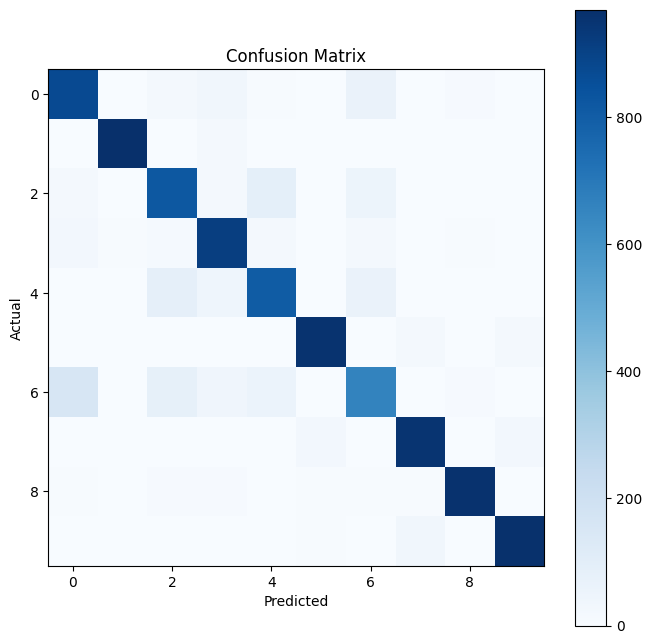

In [80]:
plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Exercise - 3

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [82]:
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.77MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 134kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.48MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]


In [83]:
train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [84]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [85]:
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784,128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = x.view(x.size(0),-1)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

In [86]:
def initialize_weights(model):

    for layer in model.modules():

        if isinstance(layer,nn.Linear):

            nn.init.kaiming_normal_(layer.weight)

            nn.init.zeros_(layer.bias)

In [87]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [88]:
model = MLP().to(device)

initialize_weights(model)

In [89]:
criterion = nn.CrossEntropyLoss()

In [90]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [91]:
def train_epoch():

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for images,labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predicted = outputs.argmax(1)

        correct += (predicted==labels).sum().item()

        total += labels.size(0)

    return total_loss/len(train_loader),100*correct/total

In [92]:
def validate():

    model.eval()

    total_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs,labels)

            total_loss += loss.item()

            predicted = outputs.argmax(1)

            correct += (predicted==labels).sum().item()

            total += labels.size(0)

    return total_loss/len(val_loader),100*correct/total

In [93]:
epochs = 20

train_losses = []

val_losses = []

val_accs = []

for epoch in range(epochs):

    train_loss,train_acc = train_epoch()

    val_loss,val_acc = validate()

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")

Epoch 1
Train Loss : 0.5705
Train Acc  : 80.46%
Val Loss   : 0.4511
Val Acc    : 83.91%
Epoch 2
Train Loss : 0.4206
Train Acc  : 85.36%
Val Loss   : 0.4053
Val Acc    : 85.51%
Epoch 3
Train Loss : 0.3785
Train Acc  : 86.73%
Val Loss   : 0.3679
Val Acc    : 87.14%
Epoch 4
Train Loss : 0.3516
Train Acc  : 87.59%
Val Loss   : 0.3717
Val Acc    : 86.85%
Epoch 5
Train Loss : 0.3321
Train Acc  : 88.14%
Val Loss   : 0.3787
Val Acc    : 86.72%
Epoch 6
Train Loss : 0.3165
Train Acc  : 88.65%
Val Loss   : 0.3371
Val Acc    : 87.95%
Epoch 7
Train Loss : 0.3020
Train Acc  : 89.06%
Val Loss   : 0.3414
Val Acc    : 87.96%
Epoch 8
Train Loss : 0.2901
Train Acc  : 89.51%
Val Loss   : 0.3295
Val Acc    : 88.32%
Epoch 9
Train Loss : 0.2770
Train Acc  : 89.86%
Val Loss   : 0.3221
Val Acc    : 88.65%
Epoch 10
Train Loss : 0.2736
Train Acc  : 90.02%
Val Loss   : 0.3115
Val Acc    : 89.31%
Epoch 11
Train Loss : 0.2619
Train Acc  : 90.49%
Val Loss   : 0.3275
Val Acc    : 88.29%
Epoch 12
Train Loss : 0.2560
T

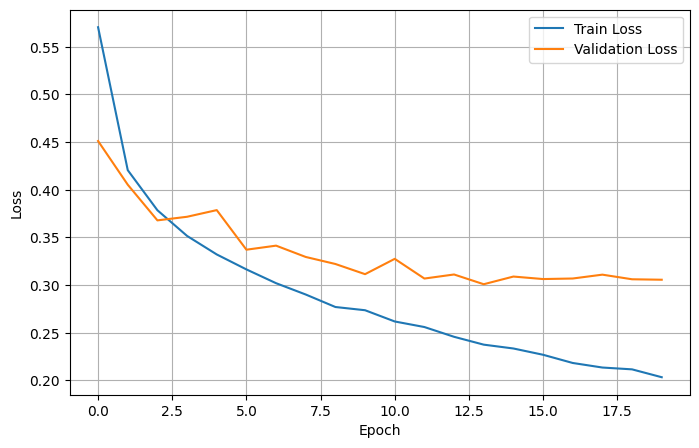

In [94]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train Loss")

plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

Exercise 4

In [95]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [96]:
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]

val_accuracy_history = {}
results = []

epochs = 20

for lr in learning_rates:

    print(f"\nTraining with learning rate = {lr}")

    # Create a fresh model
    model = MLP().to(device)
    initialize_weights(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr
    )

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Train Acc = {train_acc:.2f}% | "
            f"Val Acc = {val_acc:.2f}%"
        )

    val_accuracy_history[lr] = val_acc_list

    best_val = max(val_acc_list)

    final_train = train_acc_list[-1]

    gap = final_train - best_val

    results.append([
        lr,
        best_val,
        final_train,
        gap
    ])


Training with learning rate = 0.0001
Epoch  1 | Train Acc = 7.97% | Val Acc = 9.42%
Epoch  2 | Train Acc = 13.02% | Val Acc = 17.56%
Epoch  3 | Train Acc = 22.14% | Val Acc = 25.93%
Epoch  4 | Train Acc = 29.58% | Val Acc = 32.76%
Epoch  5 | Train Acc = 35.34% | Val Acc = 37.97%
Epoch  6 | Train Acc = 39.72% | Val Acc = 41.79%
Epoch  7 | Train Acc = 43.24% | Val Acc = 44.90%
Epoch  8 | Train Acc = 46.29% | Val Acc = 47.61%
Epoch  9 | Train Acc = 48.61% | Val Acc = 49.69%
Epoch 10 | Train Acc = 50.76% | Val Acc = 51.67%
Epoch 11 | Train Acc = 52.63% | Val Acc = 53.36%
Epoch 12 | Train Acc = 54.48% | Val Acc = 55.14%
Epoch 13 | Train Acc = 56.08% | Val Acc = 56.58%
Epoch 14 | Train Acc = 57.49% | Val Acc = 57.87%
Epoch 15 | Train Acc = 58.88% | Val Acc = 58.96%
Epoch 16 | Train Acc = 59.93% | Val Acc = 59.86%
Epoch 17 | Train Acc = 60.78% | Val Acc = 60.69%
Epoch 18 | Train Acc = 61.55% | Val Acc = 61.45%
Epoch 19 | Train Acc = 62.32% | Val Acc = 62.03%
Epoch 20 | Train Acc = 62.95% | V

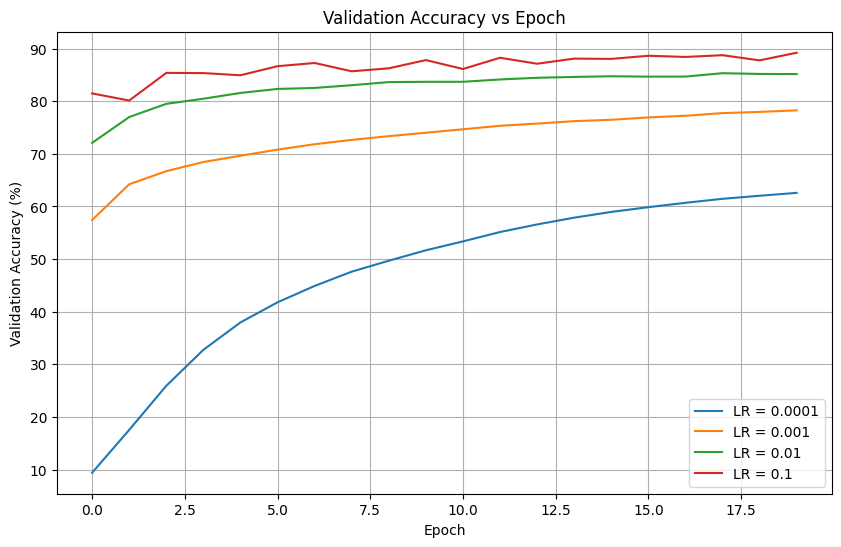

In [97]:
plt.figure(figsize=(10,6))

for lr in learning_rates:

    plt.plot(
        val_accuracy_history[lr],
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.title("Validation Accuracy vs Epoch")

plt.legend()

plt.grid(True)

plt.show()

In [98]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Learning Rate",
        "Best Val Accuracy",
        "Final Train Accuracy",
        "Train-Val Gap"
    ]
)

print(results_df)

   Learning Rate  Best Val Accuracy  Final Train Accuracy  Train-Val Gap
0         0.0001              62.58                62.952          0.372
1         0.0010              78.25                78.772          0.522
2         0.0100              85.31                85.698          0.388
3         0.1000              89.20                90.088          0.888


4.2

In [99]:
from torch.utils.data import Subset

subset_size = 8000

indices = torch.randperm(len(train_dataset))[:subset_size]

subset_dataset = Subset(train_dataset, indices)

In [100]:
from torch.utils.data import DataLoader

def create_loader(batch_size):

    return DataLoader(
        subset_dataset,
        batch_size=batch_size,
        shuffle=True
    )

In [101]:
batch_sizes = {
    "Stochastic": 1,
    "Mini-batch": 128,
    "Full-batch": 8000
}

In [102]:
import time

In [103]:
history = {}
results = []

epochs = 15

for regime, batch_size in batch_sizes.items():

    print(f"\n========== {regime} ==========")

    # Create DataLoader
    train_loader = create_loader(batch_size)

    # Fresh model
    model = MLP().to(device)

    initialize_weights(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1
    )

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_losses.append(train_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    end_time = time.time()

    wall_time = end_time - start_time

    updates = len(train_loader)

    history[regime] = {
        "loss": train_losses,
        "val_acc": val_accuracies
    }

    results.append({
        "Regime": regime,
        "Batch Size": batch_size,
        "Updates/Epoch": updates,
        "Wall Time (s)": wall_time,
        "Best Val Acc": max(val_accuracies),
        "Final Train Acc": train_acc,
        "Train-Val Gap": train_acc - max(val_accuracies)
    })


========== Stochastic ==========
Epoch  1 | Train Loss: 2.1072 | Val Acc: 22.20%
Epoch  2 | Train Loss: 2.0437 | Val Acc: 25.02%
Epoch  3 | Train Loss: 2.0632 | Val Acc: 26.41%
Epoch  4 | Train Loss: 2.1309 | Val Acc: 18.50%
Epoch  5 | Train Loss: 2.1303 | Val Acc: 16.10%
Epoch  6 | Train Loss: 2.1264 | Val Acc: 20.36%
Epoch  7 | Train Loss: 2.1037 | Val Acc: 17.12%
Epoch  8 | Train Loss: 2.1113 | Val Acc: 16.72%
Epoch  9 | Train Loss: 2.1137 | Val Acc: 17.04%
Epoch 10 | Train Loss: 2.1731 | Val Acc: 17.12%
Epoch 11 | Train Loss: 2.1317 | Val Acc: 18.55%
Epoch 12 | Train Loss: 2.0847 | Val Acc: 18.84%
Epoch 13 | Train Loss: 2.1046 | Val Acc: 17.61%
Epoch 14 | Train Loss: 2.1029 | Val Acc: 18.68%
Epoch 15 | Train Loss: 2.0836 | Val Acc: 18.31%

========== Mini-batch ==========
Epoch  1 | Train Loss: 1.0839 | Val Acc: 75.21%
Epoch  2 | Train Loss: 0.7232 | Val Acc: 74.85%
Epoch  3 | Train Loss: 0.6254 | Val Acc: 77.19%
Epoch  4 | Train Loss: 0.5691 | Val Acc: 78.34%
Epoch  5 | Train Los

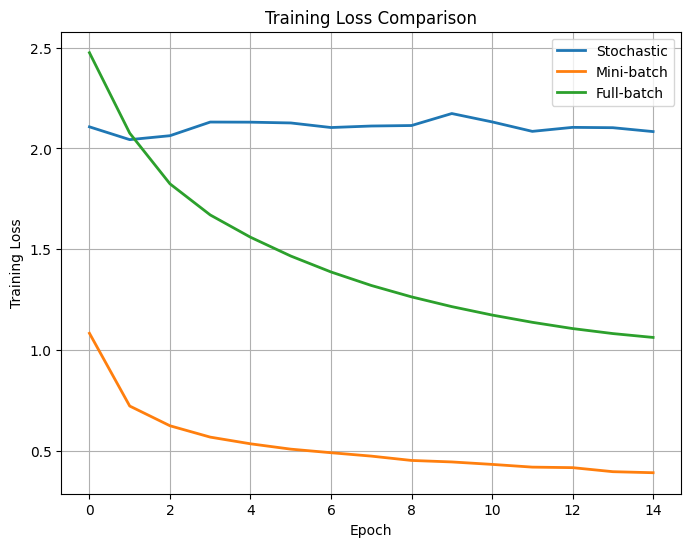

In [104]:
plt.figure(figsize=(8,6))

for regime in history:

    plt.plot(
        history[regime]["loss"],
        linewidth=2,
        label=regime
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

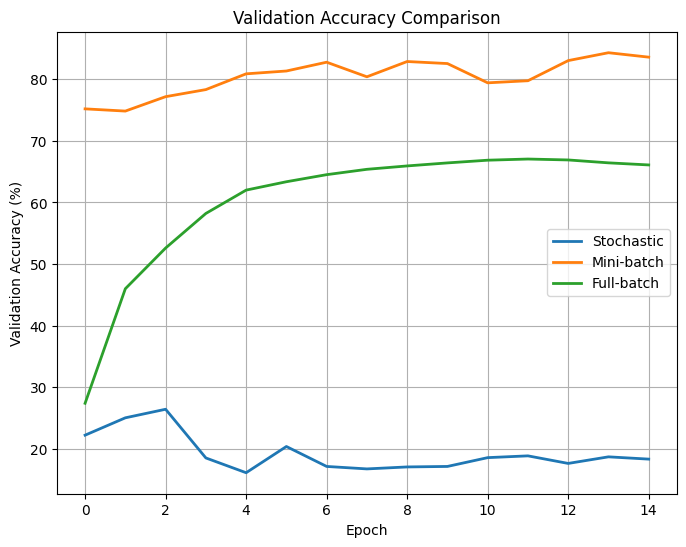

In [105]:
plt.figure(figsize=(8,6))

for regime in history:

    plt.plot(
        history[regime]["val_acc"],
        linewidth=2,
        label=regime
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [106]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Regime,Batch Size,Updates/Epoch,Wall Time (s),Best Val Acc,Final Train Acc,Train-Val Gap
0,Stochastic,1,8000,147.960164,26.41,18.5125,-7.8975
1,Mini-batch,128,63,36.994548,84.33,86.3250,1.9950
2,Full-batch,8000,1,35.697439,67.06,66.9125,-0.1475


4.3

In [107]:
class MLP(nn.Module):

    def __init__(self, hidden_layers):

        super().__init__()

        layers = []

        # Input layer
        layers.append(nn.Linear(784, 128))
        layers.append(nn.ReLU())

        # Additional hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(128, 128))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(128, 10))

        self.network = nn.Sequential(*layers)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

In [108]:
depths = [1, 2, 3, 5]

In [109]:
history = {}
results = []

epochs = 20

for depth in depths:

    print(f"\nTraining with {depth} hidden layer(s)")

    model = MLP(hidden_layers=depth).to(device)

    initialize_weights(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1
    )

    train_acc_history = []
    val_acc_history = []

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

    history[depth] = val_acc_history

    results.append({
        "Hidden Layers": depth,
        "Best Validation Accuracy": max(val_acc_history),
        "Final Train Accuracy": train_acc_history[-1],
        "Train-Val Gap": train_acc_history[-1] - max(val_acc_history)
    })


Training with 1 hidden layer(s)

Training with 2 hidden layer(s)

Training with 3 hidden layer(s)

Training with 5 hidden layer(s)


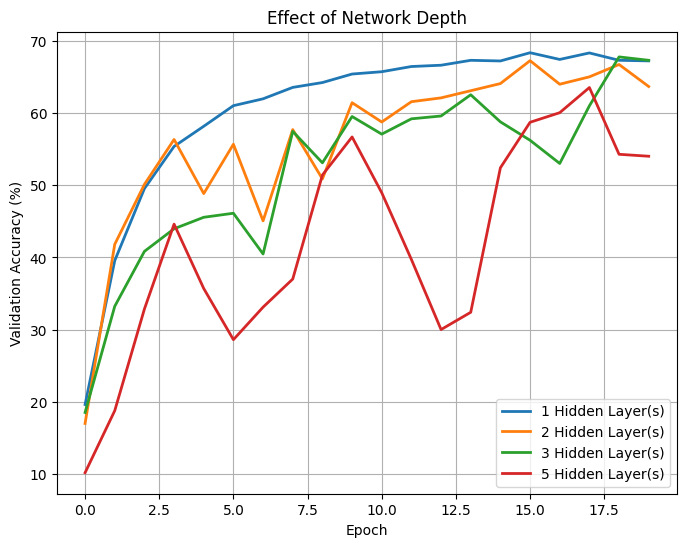

In [110]:
plt.figure(figsize=(8,6))

for depth in depths:

    plt.plot(
        history[depth],
        linewidth=2,
        label=f"{depth} Hidden Layer(s)"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Effect of Network Depth")
plt.legend()
plt.grid(True)
plt.show()

In [111]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Hidden Layers,Best Validation Accuracy,Final Train Accuracy,Train-Val Gap
0,1,68.34,67.325,-1.015
1,2,67.24,67.325,0.085
2,3,67.76,68.025,0.265
3,5,63.52,54.975,-8.545


4.4

In [112]:
import torch
import torch.nn as nn

class WidthMLP(nn.Module):

    def __init__(self, hidden_units):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, 10)
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

In [113]:
widths = [32, 128, 512]

history = {}

results = []

epochs = 20

for width in widths:

    print("=" * 60)
    print(f"Training Width = {width}")
    print("=" * 60)

    model = WidthMLP(width).to(device)

    initialize_weights(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1
    )

    train_acc_list = []

    val_acc_list = []

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_acc_list.append(train_acc)

        val_acc_list.append(val_acc)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Train Acc = {train_acc:.2f}% | "
            f"Val Acc = {val_acc:.2f}%"
        )

    history[width] = val_acc_list

    results.append([
        width,
        max(val_acc_list),
        train_acc_list[-1],
        train_acc_list[-1]-max(val_acc_list)
    ])

Training Width = 32
Epoch  1 | Train Acc = 12.55% | Val Acc = 13.32%
Epoch  2 | Train Acc = 13.61% | Val Acc = 28.17%
Epoch  3 | Train Acc = 28.75% | Val Acc = 31.59%
Epoch  4 | Train Acc = 32.29% | Val Acc = 41.95%
Epoch  5 | Train Acc = 42.12% | Val Acc = 40.67%
Epoch  6 | Train Acc = 41.23% | Val Acc = 43.40%
Epoch  7 | Train Acc = 43.62% | Val Acc = 43.61%
Epoch  8 | Train Acc = 44.50% | Val Acc = 45.64%
Epoch  9 | Train Acc = 46.14% | Val Acc = 46.26%
Epoch 10 | Train Acc = 46.94% | Val Acc = 47.99%
Epoch 11 | Train Acc = 48.27% | Val Acc = 48.35%
Epoch 12 | Train Acc = 49.42% | Val Acc = 49.65%
Epoch 13 | Train Acc = 49.42% | Val Acc = 49.58%
Epoch 14 | Train Acc = 51.06% | Val Acc = 52.40%
Epoch 15 | Train Acc = 52.21% | Val Acc = 54.36%
Epoch 16 | Train Acc = 55.45% | Val Acc = 57.07%
Epoch 17 | Train Acc = 56.73% | Val Acc = 58.04%
Epoch 18 | Train Acc = 59.02% | Val Acc = 60.05%
Epoch 19 | Train Acc = 59.83% | Val Acc = 59.78%
Epoch 20 | Train Acc = 60.41% | Val Acc = 61.62%


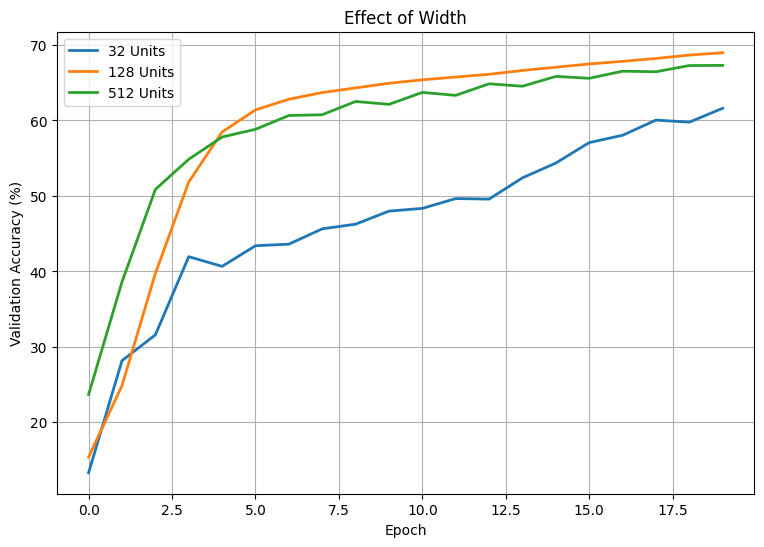

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

for width in widths:

    plt.plot(
        history[width],
        linewidth=2,
        label=f"{width} Units"
    )

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.title("Effect of Width")

plt.grid(True)

plt.legend()

plt.show()

In [115]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Hidden Units",
        "Best Val Accuracy",
        "Final Train Accuracy",
        "Train-Val Gap"
    ]
)

results_df

,Hidden Units,Best Val Accuracy,Final Train Accuracy,Train-Val Gap
0,32,61.62,60.4125,-1.2075
1,128,68.98,68.9875,0.0075
2,512,67.30,67.2625,-0.0375


In [116]:
for width in widths:

    model = WidthMLP(width)

    total = sum(p.numel() for p in model.parameters())

    print(f"{width} units --> {total:,} parameters")

32 units --> 25,450 parameters
128 units --> 101,770 parameters
512 units --> 407,050 parameters


4.5

In [117]:
class ActivationMLP(nn.Module):

    def __init__(self, activation):

        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.activation = activation
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)

        return x

In [118]:
def initialize_activation_weights(model, activation_name):

    for m in model.modules():

        if isinstance(m, nn.Linear):

            if activation_name in ["Sigmoid", "Tanh"]:

                nn.init.xavier_uniform_(m.weight)

            else:

                nn.init.kaiming_uniform_(
                    m.weight,
                    nonlinearity="relu"
                )

            nn.init.zeros_(m.bias)

In [119]:
activations = {

    "Sigmoid": nn.Sigmoid(),

    "Tanh": nn.Tanh(),

    "ReLU": nn.ReLU(),

    "LeakyReLU": nn.LeakyReLU(negative_slope=0.01)
}

In [120]:
history = {}

results = []

epochs = 20

for name, activation in activations.items():

    print("="*60)
    print(f"Activation : {name}")
    print("="*60)

    model = ActivationMLP(activation).to(device)

    initialize_activation_weights(model, name)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1
    )

    train_acc_list = []

    val_acc_list = []

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Train Acc = {train_acc:.2f}% | "
            f"Val Acc = {val_acc:.2f}%"
        )

    history[name] = val_acc_list

    results.append([
        name,
        max(val_acc_list),
        train_acc_list[-1],
        train_acc_list[-1]-max(val_acc_list)
    ])

Activation : Sigmoid
Epoch  1 | Train Acc = 16.51% | Val Acc = 21.53%
Epoch  2 | Train Acc = 20.85% | Val Acc = 23.79%
Epoch  3 | Train Acc = 22.96% | Val Acc = 25.39%
Epoch  4 | Train Acc = 24.81% | Val Acc = 27.93%
Epoch  5 | Train Acc = 27.41% | Val Acc = 31.77%
Epoch  6 | Train Acc = 31.21% | Val Acc = 36.42%
Epoch  7 | Train Acc = 36.31% | Val Acc = 40.50%
Epoch  8 | Train Acc = 40.65% | Val Acc = 43.55%
Epoch  9 | Train Acc = 43.91% | Val Acc = 45.88%
Epoch 10 | Train Acc = 46.61% | Val Acc = 48.08%
Epoch 11 | Train Acc = 48.80% | Val Acc = 49.73%
Epoch 12 | Train Acc = 50.34% | Val Acc = 51.23%
Epoch 13 | Train Acc = 51.52% | Val Acc = 52.23%
Epoch 14 | Train Acc = 52.81% | Val Acc = 53.25%
Epoch 15 | Train Acc = 53.81% | Val Acc = 54.04%
Epoch 16 | Train Acc = 54.80% | Val Acc = 54.87%
Epoch 17 | Train Acc = 55.45% | Val Acc = 55.69%
Epoch 18 | Train Acc = 56.42% | Val Acc = 56.32%
Epoch 19 | Train Acc = 57.15% | Val Acc = 56.87%
Epoch 20 | Train Acc = 58.00% | Val Acc = 57.39%

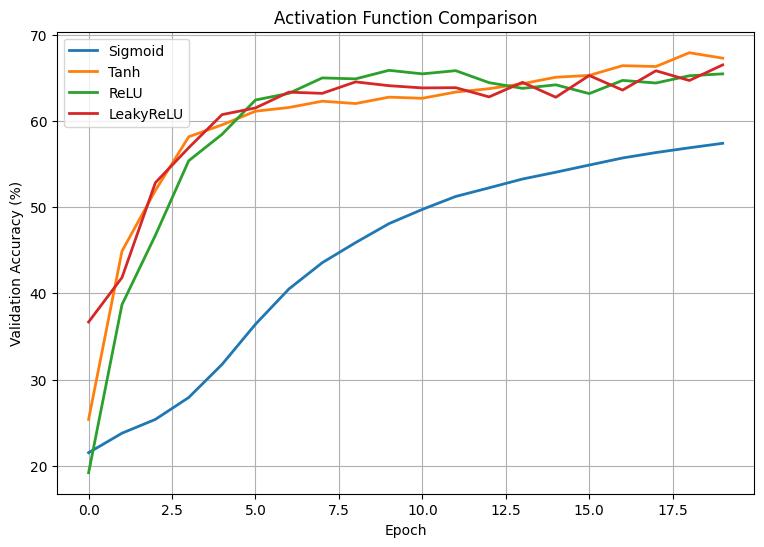

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

for name in activations.keys():

    plt.plot(
        history[name],
        linewidth=2,
        label=name
    )

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy (%)")

plt.title("Activation Function Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [122]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Activation",
        "Best Validation Accuracy",
        "Final Train Accuracy",
        "Train-Val Gap"
    ]
)

results_df

,Activation,Best Validation Accuracy,Final Train Accuracy,Train-Val Gap
0,Sigmoid,57.39,58.0000,0.6100
1,Tanh,67.89,69.2500,1.3600
2,ReLU,65.85,65.7875,-0.0625
3,LeakyReLU,66.48,64.8000,-1.6800


4.6

In [123]:
class DeepSigmoidMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784,128),
            nn.Sigmoid(),

            nn.Linear(128,128),
            nn.Sigmoid(),

            nn.Linear(128,128),
            nn.Sigmoid(),

            nn.Linear(128,128),
            nn.Sigmoid(),

            nn.Linear(128,10)

        )

    def forward(self,x):

        x = x.view(x.size(0),-1)

        return self.network(x)

In [124]:
def initialize_model(model, method):

    for layer in model.modules():

        if isinstance(layer, nn.Linear):

            if method == "Small":

                nn.init.constant_(layer.weight,0.01)

            elif method == "Large":

                nn.init.normal_(layer.weight,mean=0,std=5)

            elif method == "Xavier":

                nn.init.xavier_uniform_(layer.weight)

            elif method == "He":

                nn.init.kaiming_uniform_(
                    layer.weight,
                    nonlinearity="relu"
                )

            nn.init.zeros_(layer.bias)

In [125]:
methods = [

    "Small",

    "Large",

    "Xavier",

    "He"

]

In [126]:
history = {}

results = []

epochs = 20

for method in methods:

    print("="*60)
    print(method)
    print("="*60)

    model = DeepSigmoidMLP().to(device)

    initialize_model(model,method)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.1
    )

    train_acc_history = []

    val_acc_history = []

    for epoch in range(epochs):

        train_loss,train_acc = train_epoch()

        val_loss,val_acc = validate()

        train_acc_history.append(train_acc)

        val_acc_history.append(val_acc)

        print(
            f"Epoch {epoch+1:2d}"
            f" Train={train_acc:.2f}"
            f" Val={val_acc:.2f}"
        )

    history[method]=val_acc_history

    results.append([
        method,
        max(val_acc_history),
        train_acc_history[-1],
        train_acc_history[-1]-max(val_acc_history)
    ])

Small
Epoch  1 Train=10.05 Val=9.86
Epoch  2 Train=10.36 Val=9.86
Epoch  3 Train=10.36 Val=9.86
Epoch  4 Train=10.36 Val=9.86
Epoch  5 Train=10.36 Val=9.86
Epoch  6 Train=10.36 Val=9.86
Epoch  7 Train=10.36 Val=9.86
Epoch  8 Train=10.36 Val=9.86
Epoch  9 Train=10.36 Val=9.86
Epoch 10 Train=10.36 Val=9.86
Epoch 11 Train=10.36 Val=9.86
Epoch 12 Train=10.36 Val=9.86
Epoch 13 Train=10.36 Val=9.86
Epoch 14 Train=10.36 Val=9.86
Epoch 15 Train=10.36 Val=9.86
Epoch 16 Train=10.36 Val=9.86
Epoch 17 Train=10.36 Val=9.86
Epoch 18 Train=10.36 Val=9.86
Epoch 19 Train=10.36 Val=9.86
Epoch 20 Train=10.36 Val=9.86
Large
Epoch  1 Train=8.95 Val=9.49
Epoch  2 Train=9.11 Val=9.36
Epoch  3 Train=9.57 Val=9.57
Epoch  4 Train=9.85 Val=9.75
Epoch  5 Train=10.32 Val=10.08
Epoch  6 Train=11.01 Val=10.41
Epoch  7 Train=11.09 Val=10.27
Epoch  8 Train=11.65 Val=10.48
Epoch  9 Train=11.76 Val=10.50
Epoch 10 Train=11.96 Val=10.50
Epoch 11 Train=12.44 Val=10.67
Epoch 12 Train=12.19 Val=10.66
Epoch 13 Train=12.72 Val

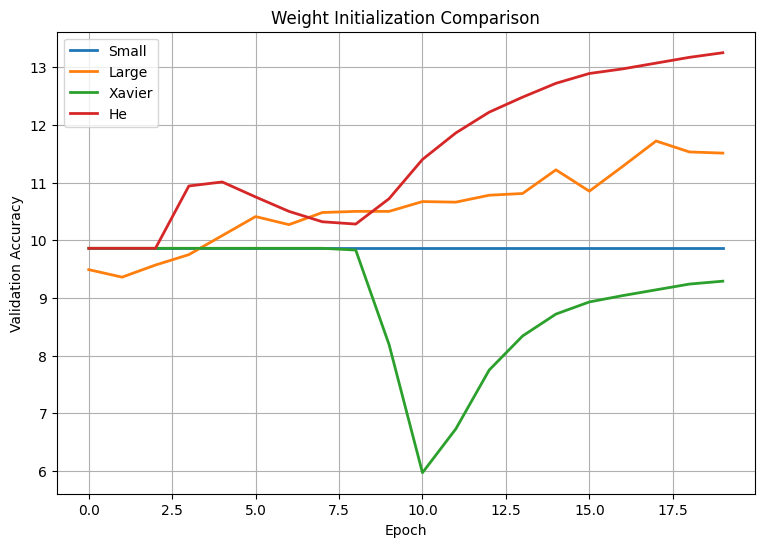

In [127]:
plt.figure(figsize=(9,6))

for method in methods:

    plt.plot(
        history[method],
        linewidth=2,
        label=method
    )

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Weight Initialization Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [128]:
import pandas as pd

results_df = pd.DataFrame(

    results,

    columns=[

        "Initialization",

        "Best Validation Accuracy",

        "Final Train Accuracy",

        "Train-Val Gap"

    ]

)

results_df

,Initialization,Best Validation Accuracy,Final Train Accuracy,Train-Val Gap
0,Small,9.86,10.3625,0.5025
1,Large,11.72,14.2875,2.5675
2,Xavier,9.86,9.4500,-0.4100
3,He,13.25,13.7000,0.4500


4.7

In [129]:
class OptimizerMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = x.view(x.size(0),-1)

        return self.network(x)

In [130]:
optimizers = {

    "SGD":
        lambda params: optim.SGD(
            params,
            lr=1e-3
        ),

    "Momentum":
        lambda params: optim.SGD(
            params,
            lr=1e-3,
            momentum=0.9
        ),

    "RMSProp":
        lambda params: optim.RMSprop(
            params,
            lr=1e-3
        ),

    "Adam":
        lambda params: optim.Adam(
            params,
            lr=1e-3
        )
}

In [131]:
history = {}

results = []

epochs = 20

for name, optimizer_fn in optimizers.items():

    print("=" * 60)
    print(f"Optimizer: {name}")
    print("=" * 60)

    model = OptimizerMLP().to(device)

    initialize_weights(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = optimizer_fn(model.parameters())

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        train_loss, train_acc = train_epoch()

        val_loss, val_acc = validate()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Train={train_acc:.2f}% | "
            f"Val={val_acc:.2f}%"
        )

    history[name] = val_acc_list

    results.append([
        name,
        max(val_acc_list),
        train_acc_list[-1],
        train_acc_list[-1] - max(val_acc_list)
    ])

Optimizer: SGD
Epoch  1 | Train=10.25% | Val=10.21%
Epoch  2 | Train=10.32% | Val=10.30%
Epoch  3 | Train=10.44% | Val=10.36%
Epoch  4 | Train=10.54% | Val=10.40%
Epoch  5 | Train=10.60% | Val=10.55%
Epoch  6 | Train=10.68% | Val=10.62%
Epoch  7 | Train=10.72% | Val=10.69%
Epoch  8 | Train=10.89% | Val=10.83%
Epoch  9 | Train=10.95% | Val=10.90%
Epoch 10 | Train=11.00% | Val=11.00%
Epoch 11 | Train=11.09% | Val=11.09%
Epoch 12 | Train=11.26% | Val=11.22%
Epoch 13 | Train=11.39% | Val=11.30%
Epoch 14 | Train=11.45% | Val=11.50%
Epoch 15 | Train=11.51% | Val=11.55%
Epoch 16 | Train=11.62% | Val=11.65%
Epoch 17 | Train=11.72% | Val=11.70%
Epoch 18 | Train=11.84% | Val=11.76%
Epoch 19 | Train=12.00% | Val=11.85%
Epoch 20 | Train=12.06% | Val=12.11%
Optimizer: Momentum
Epoch  1 | Train=13.74% | Val=14.38%
Epoch  2 | Train=13.80% | Val=14.42%
Epoch  3 | Train=13.95% | Val=14.54%
Epoch  4 | Train=14.03% | Val=14.61%
Epoch  5 | Train=14.11% | Val=14.82%
Epoch  6 | Train=14.29% | Val=15.02%
Epo

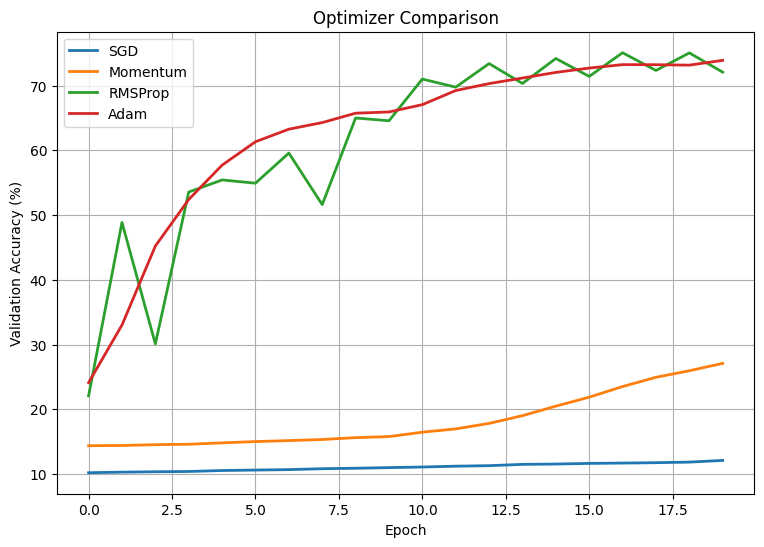

In [132]:
plt.figure(figsize=(9,6))

for name in history:

    plt.plot(
        history[name],
        linewidth=2,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [133]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Optimizer",
        "Best Validation Accuracy",
        "Final Train Accuracy",
        "Train-Val Gap"
    ]
)

results_df

,Optimizer,Best Validation Accuracy,Final Train Accuracy,Train-Val Gap
0,SGD,12.11,12.0625,-0.0475
1,Momentum,27.10,25.8375,-1.2625
2,RMSProp,75.08,75.7000,0.6200
3,Adam,73.90,74.4000,0.5000


4.8

In [134]:
class RegularizedMLP(nn.Module):

    def __init__(self, dropout=False):

        super().__init__()

        layers = [

            nn.Linear(784,512),

            nn.ReLU()

        ]

        if dropout:

            layers.append(nn.Dropout(0.5))

        layers.extend([

            nn.Linear(512,512),

            nn.ReLU()

        ])

        if dropout:

            layers.append(nn.Dropout(0.5))

        layers.append(

            nn.Linear(512,10)

        )

        self.network = nn.Sequential(*layers)

    def forward(self,x):

        x=x.view(x.size(0),-1)

        return self.network(x)

In [135]:
configs={

    "None":{

        "dropout":False,

        "weight_decay":0

    },

    "L2":{

        "dropout":False,

        "weight_decay":1e-4

    },

    "Dropout":{

        "dropout":True,

        "weight_decay":0

    },

    "L2+Dropout":{

        "dropout":True,

        "weight_decay":1e-4

    }

}

In [136]:
history={}

results=[]

epochs=25

for name,config in configs.items():

    print("="*60)

    print(name)

    print("="*60)

    model=RegularizedMLP(

        dropout=config["dropout"]

    ).to(device)

    initialize_weights(model)

    criterion=nn.CrossEntropyLoss()

    optimizer=optim.Adam(

        model.parameters(),

        lr=1e-3,

        weight_decay=config["weight_decay"]

    )

    train_loss_list=[]

    val_loss_list=[]

    train_acc_list=[]

    val_acc_list=[]

    for epoch in range(epochs):

        train_loss,train_acc=train_epoch()

        val_loss,val_acc=validate()

        train_loss_list.append(train_loss)

        val_loss_list.append(val_loss)

        train_acc_list.append(train_acc)

        val_acc_list.append(val_acc)

        print(

            f"Epoch {epoch+1:2d}"

            f" Train={train_acc:.2f}"

            f" Val={val_acc:.2f}"

        )

    history[name]={

        "train_loss":train_loss_list,

        "val_loss":val_loss_list,

        "val_acc":val_acc_list

    }

    results.append([

        name,

        max(val_acc_list),

        train_acc_list[-1],

        train_acc_list[-1]-max(val_acc_list)

    ])

None
Epoch  1 Train=5.59 Val=36.71
Epoch  2 Train=35.74 Val=58.82
Epoch  3 Train=59.67 Val=63.28
Epoch  4 Train=63.88 Val=68.21
Epoch  5 Train=68.26 Val=71.35
Epoch  6 Train=72.40 Val=71.82
Epoch  7 Train=73.50 Val=73.72
Epoch  8 Train=74.79 Val=74.42
Epoch  9 Train=75.67 Val=74.37
Epoch 10 Train=76.08 Val=76.94
Epoch 11 Train=78.53 Val=77.30
Epoch 12 Train=78.39 Val=77.56
Epoch 13 Train=78.90 Val=78.49
Epoch 14 Train=79.79 Val=78.66
Epoch 15 Train=79.61 Val=79.82
Epoch 16 Train=80.96 Val=79.43
Epoch 17 Train=81.00 Val=79.84
Epoch 18 Train=80.60 Val=80.84
Epoch 19 Train=81.89 Val=79.75
Epoch 20 Train=81.33 Val=81.08
Epoch 21 Train=82.22 Val=80.84
Epoch 22 Train=81.79 Val=81.93
Epoch 23 Train=83.05 Val=81.87
Epoch 24 Train=82.89 Val=82.07
Epoch 25 Train=83.36 Val=82.69
L2
Epoch  1 Train=10.22 Val=34.60
Epoch  2 Train=33.73 Val=52.35
Epoch  3 Train=52.17 Val=64.45
Epoch  4 Train=64.36 Val=66.59
Epoch  5 Train=66.64 Val=69.65
Epoch  6 Train=70.42 Val=72.05
Epoch  7 Train=72.69 Val=74.02
E

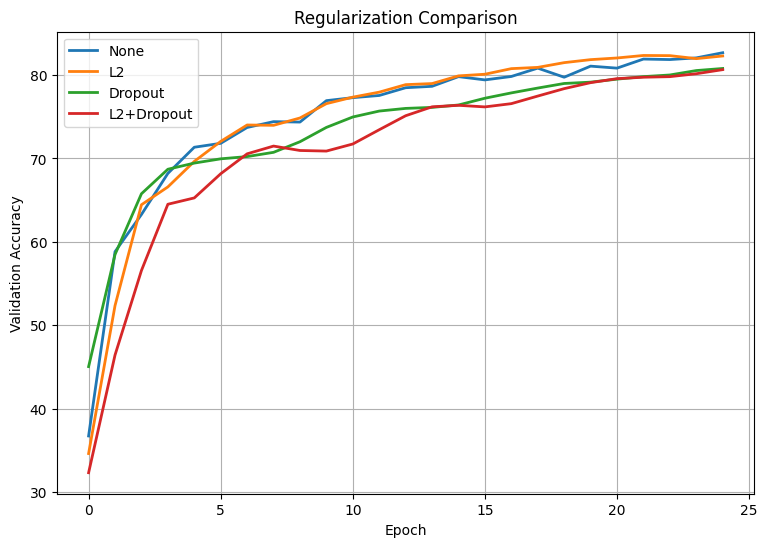

In [137]:
plt.figure(figsize=(9,6))

for name in history:

    plt.plot(

        history[name]["val_acc"],

        linewidth=2,

        label=name

    )

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Regularization Comparison")

plt.legend()

plt.grid()

plt.show()

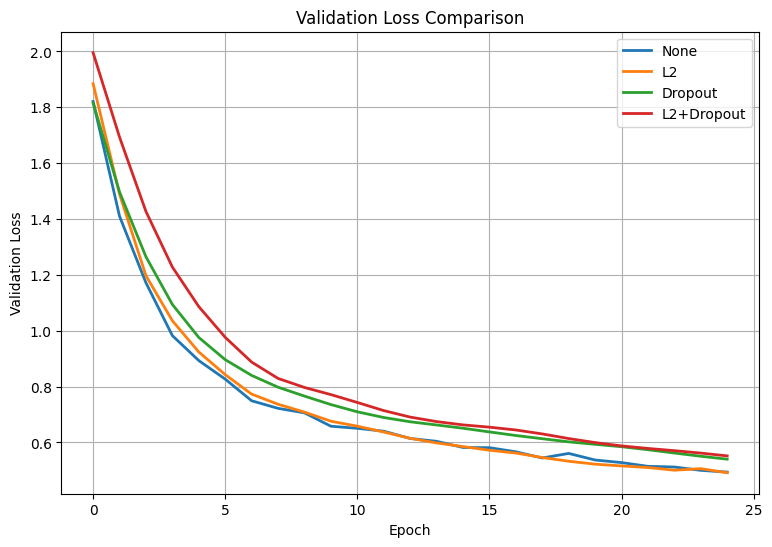

In [138]:
plt.figure(figsize=(9,6))

for name in history:

    plt.plot(

        history[name]["val_loss"],

        linewidth=2,

        label=name

    )

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss Comparison")

plt.legend()

plt.grid()

plt.show()

In [139]:
import pandas as pd

results_df=pd.DataFrame(

    results,

    columns=[

        "Configuration",

        "Best Validation Accuracy",

        "Final Train Accuracy",

        "Train-Val Gap"

    ]

)

results_df

,Configuration,Best Validation Accuracy,Final Train Accuracy,Train-Val Gap
0,None,82.69,83.3625,0.6725
1,L2,82.36,83.4250,1.0650
2,Dropout,80.80,77.4625,-3.3375
3,L2+Dropout,80.66,77.9875,-2.6725


Exercise 5

In [140]:
class BestMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784,512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512,512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512,10)

        )

    def forward(self,x):

        x=x.view(x.size(0),-1)

        return self.network(x)

In [141]:
model = BestMLP().to(device)

initialize_weights(model)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [142]:
best_loss = float("inf")

patience = 5

counter = 0

epochs = 50

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

In [143]:
for epoch in range(epochs):

    train_loss, train_acc = train_epoch()

    val_loss, val_acc = validate()

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} "
        f"Train Loss={train_loss:.4f} "
        f"Val Loss={val_loss:.4f} "
        f"Train Acc={train_acc:.2f}% "
        f"Val Acc={val_acc:.2f}%"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    else:

        counter += 1

    if counter >= patience:

        print("Early Stopping Triggered")

        break

Epoch  1 Train Loss=2.8462 Val Loss=1.8866 Train Acc=10.15% Val Acc=50.89%
Epoch  2 Train Loss=2.1843 Val Loss=1.5015 Train Acc=24.43% Val Acc=58.25%
Epoch  3 Train Loss=1.7687 Val Loss=1.2529 Train Acc=38.67% Val Acc=63.24%
Epoch  4 Train Loss=1.4934 Val Loss=1.1008 Train Acc=48.81% Val Acc=63.50%
Epoch  5 Train Loss=1.3444 Val Loss=0.9719 Train Acc=53.58% Val Acc=67.47%
Epoch  6 Train Loss=1.2097 Val Loss=0.8845 Train Acc=57.65% Val Acc=71.41%
Epoch  7 Train Loss=1.1205 Val Loss=0.8308 Train Acc=60.65% Val Acc=70.94%
Epoch  8 Train Loss=1.0507 Val Loss=0.7882 Train Acc=61.89% Val Acc=71.69%
Epoch  9 Train Loss=0.9874 Val Loss=0.7530 Train Acc=64.21% Val Acc=72.47%
Epoch 10 Train Loss=0.9455 Val Loss=0.7282 Train Acc=65.24% Val Acc=73.19%
Epoch 11 Train Loss=0.8947 Val Loss=0.7036 Train Acc=67.22% Val Acc=74.01%
Epoch 12 Train Loss=0.8707 Val Loss=0.6839 Train Acc=68.05% Val Acc=75.13%
Epoch 13 Train Loss=0.8423 Val Loss=0.6710 Train Acc=69.80% Val Acc=75.60%
Epoch 14 Train Loss=0.809

In [144]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

BestMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [145]:
print(val_loader)

In [146]:
correct = 0

total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy : {test_accuracy:.2f}%")

Test Accuracy : 84.55%


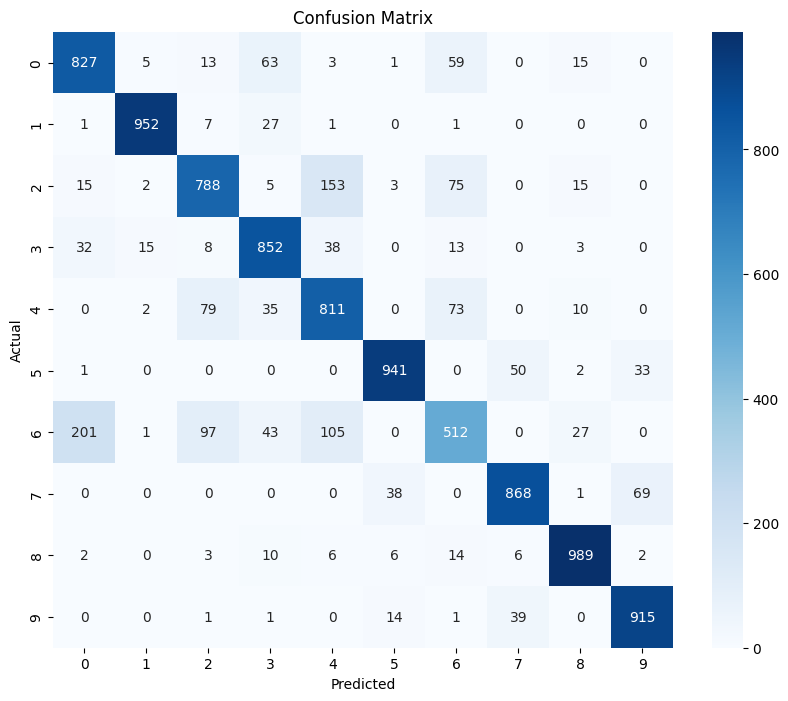

In [147]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [148]:
from sklearn.metrics import classification_report

classes = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

 T-shirt/Top       0.77      0.84      0.80       986
     Trouser       0.97      0.96      0.97       989
    Pullover       0.79      0.75      0.77      1056
       Dress       0.82      0.89      0.85       961
        Coat       0.73      0.80      0.76      1010
      Sandal       0.94      0.92      0.93      1027
       Shirt       0.68      0.52      0.59       986
     Sneaker       0.90      0.89      0.90       976
         Bag       0.93      0.95      0.94      1038
  Ankle Boot       0.90      0.94      0.92       971

    accuracy                           0.85     10000
   macro avg       0.84      0.85      0.84     10000
weighted avg       0.84      0.85      0.84     10000

